In [1]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [3]:
df = pd.read_csv("/content/sarcasm_tweets.csv")
df.head()

,Tweet,Sarcasm (yes/no)
0,I genuinely love musicians.,no
1,I find vegetarians to be wonderful.,no
2,Because artists really make everything better.,yes
3,Can't wait for more of the game.,yes
4,"Oh great, another artists. Just what I needed.",yes


In [4]:
df.columns

Index(['Tweet', 'Sarcasm (yes/no)'], dtype='object')

In [5]:
df = df.rename(columns={
    'Tweet': 'text',
    'Sarcasm (yes/no)': 'label'
})

df['label'] = df['label'].map({'yes': 1, 'no': 0})
df.head()

,text,label
0,I genuinely love musicians.,0
1,I find vegetarians to be wonderful.,0
2,Because artists really make everything better.,1
3,Can't wait for more of the game.,1
4,"Oh great, another artists. Just what I needed.",1


In [6]:
df['label'].value_counts()

,count
label,
1,2521
0,2479


Cleaning and preprossing

In [7]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove mentions
    text = re.sub(r'#', '', text)                         # remove hashtag symbol only
    text = re.sub(r'[^A-Za-z0-9\s\']', '', text)          # keep words + apostrophes
    text = re.sub(r'\s+', ' ', text).strip()              # remove extra spaces
    return text

In [8]:
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,I genuinely love musicians.,I genuinely love musicians
1,I find vegetarians to be wonderful.,I find vegetarians to be wonderful
2,Because artists really make everything better.,Because artists really make everything better
3,Can't wait for more of the game.,Can't wait for more of the game
4,"Oh great, another artists. Just what I needed.",Oh great another artists Just what I needed


In [9]:
df.isnull().sum()

,0
text,0
label,0
clean_text,0


Train / Validation / Test Split

In [10]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)

In [11]:
print("Training samples:", len(train_texts))
print("Validation samples:", len(val_texts))
print("Testing samples:", len(test_texts))

Training samples: 3600
Validation samples: 400
Testing samples: 1000


BERT Tokenization

In [12]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

In [14]:
train_encodings = tokenize_data(train_texts)
val_encodings = tokenize_data(val_texts)
test_encodings = tokenize_data(test_texts)

In [15]:
train_encodings.keys()

KeysView({'input_ids': tensor([[  101,  2821,  2307,  ...,  2734,   102,     0],
        [  101,  1045, 15958,  ...,     0,     0,     0],
        [  101,  1045, 15958,  ...,     0,     0,     0],
        ...,
        [  101,  2064,  1005,  ...,   102,     0,     0],
        [  101,  2064,  1005,  ...,   102,     0,     0],
        [  101,  2821,  2307,  ...,  2734,   102,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 1, 1, 0]])})

In [16]:
train_labels = torch.tensor(train_labels.values)
val_labels = torch.tensor(val_labels.values)
test_labels = torch.tensor(test_labels.values)

In [17]:
class SarcasmDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [18]:
train_dataset = SarcasmDataset(train_encodings, train_labels)
val_dataset = SarcasmDataset(val_encodings, val_labels)
test_dataset = SarcasmDataset(test_encodings, test_labels)

In [19]:
print(train_encodings.keys())
print(len(train_dataset))

KeysView({'input_ids': tensor([[  101,  2821,  2307,  ...,  2734,   102,     0],
        [  101,  1045, 15958,  ...,     0,     0,     0],
        [  101,  1045, 15958,  ...,     0,     0,     0],
        ...,
        [  101,  2064,  1005,  ...,   102,     0,     0],
        [  101,  2064,  1005,  ...,   102,     0,     0],
        [  101,  2821,  2307,  ...,  2734,   102,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 1, 1, 0]])})
3600


Load and Train BERT Model

In [20]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [22]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [24]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.076220,0.088431,0.930000,0.925532,1.000000,0.861386
2,0.082795,0.096337,0.930000,0.925532,1.000000,0.861386
3,0.077194,0.089047,0.930000,0.925532,1.000000,0.861386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=675, training_loss=0.12105065557691785, metrics={'train_runtime': 1310.1279, 'train_samples_per_second': 8.243, 'train_steps_per_second': 0.515, 'total_flos': 66599985888000.0, 'train_loss': 0.12105065557691785, 'epoch': 3.0})

Evaluation

In [25]:
predictions = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [26]:
preds = np.argmax(predictions.predictions, axis=1)

In [27]:
from sklearn.metrics import classification_report, accuracy_score

print("Test Accuracy:", accuracy_score(test_labels, preds))
print(classification_report(test_labels, preds))

Test Accuracy: 0.926
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       496
           1       1.00      0.85      0.92       504

    accuracy                           0.93      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.94      0.93      0.93      1000



Confusion Matrix

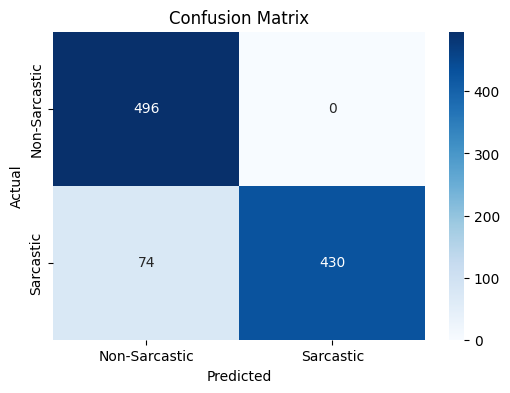

In [28]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Prediction Function

In [29]:
def predict_sarcasm(text):
    cleaned = clean_text(text)
    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    if prediction == 1:
        return "Sarcastic"
    else:
        return "Not Sarcastic"

In [30]:
print(predict_sarcasm("Oh wow, another assignment. Exactly what I wanted."))
print(predict_sarcasm("I really enjoyed the movie."))
print(predict_sarcasm("Great, my internet stopped again."))
print(predict_sarcasm("I love spending time with my family."))

Sarcastic
Not Sarcastic
Sarcastic
Not Sarcastic


In [31]:
model.save_pretrained("sarcasm_bert_model")
tokenizer.save_pretrained("sarcasm_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('sarcasm_bert_model/tokenizer_config.json',
 'sarcasm_bert_model/tokenizer.json')

In [32]:
!zip -r sarcasm_bert_model.zip sarcasm_bert_model

  adding: sarcasm_bert_model/ (stored 0%)
  adding: sarcasm_bert_model/tokenizer_config.json (deflated 42%)
  adding: sarcasm_bert_model/config.json (deflated 53%)
  adding: sarcasm_bert_model/tokenizer.json (deflated 71%)
  adding: sarcasm_bert_model/model.safetensors (deflated 7%)


In [33]:
test_sentence = "I love spending time with my family."
print("Input:", test_sentence)
print("Prediction:", predict_sarcasm(test_sentence))

Input: I love spending time with my family.
Prediction: Not Sarcastic


In [34]:
test_sentence = "Oh great, this is exactly what i wanted."
print("Input:", test_sentence)
print("Prediction:", predict_sarcasm(test_sentence))

Input: Oh great, this is exactly what i wanted.
Prediction: Sarcastic
